<table style="border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:middle; width:500px;">
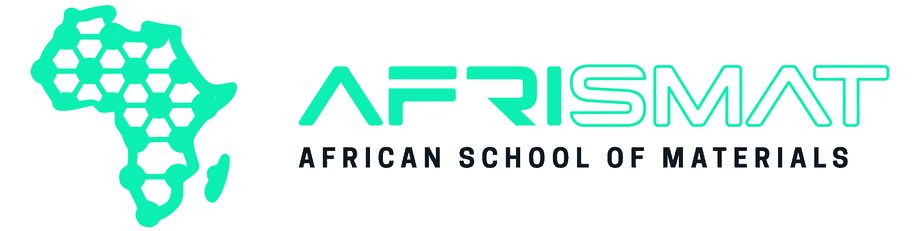
</td>
<td style="border:none; vertical-align:middle;">

# **A-IDI: Africa Inclusive Digital Industries 2026**
> ## **Circular Mechatronics 4 Africa (CM4A)**
> ### **Introduction to robotics online lab exercise 1**

</td>
</tr></table>


# **Driving a Mobile Robot with Nonlinear Model Predictive Control**
> ### **Build the controller yourself, one piece at a time**

A mobile robot must cross a factory floor. Equipment is in the way.

**In this workshop you will build a controller similar to the one in the video after the setup cell: it drives the robot to an inspection point without touching the equipment.**

You will write the controller in five tasks, each with a hint, a solution and a check that must print **PASS**. One more task, marked **Explain**, asks for a sentence or two instead of code: write your answer in the cell below the question before you open the answer. Then you will run the controller on a simulated robot and test how far ahead it needs to look.

No control background is needed. Every value marked `EDIT` is there to be changed. Run the cells in order. Change only the cells you are asked to: the task cells, the answer cells under each **Explain**, and the lines marked `EDIT`. The rest are locked, so that nothing can be changed by accident. If something stops working, open a fresh copy from the link in the README.

This is the first of two notebooks. The quadrotor notebook comes next and builds on this one.

## **0. Setting up**

Run this cell. It should finish by printing `ready`.

In [ ]:
%pip install -q mujoco casadi "imageio[ffmpeg]"

import os, sys, urllib.request

LIBRARY = "robot_lab.py"
REPO = "https://raw.githubusercontent.com/JohnEkD/nmpc-workshop/main/"

# the workshop code lives in the lib folder beside this notebook; anything
# missing is downloaded from the repository
os.makedirs("lib", exist_ok=True)
in_colab = os.path.isdir("/content")          # on Colab, always take a fresh copy
for name in (LIBRARY, "common.py"):
    path = os.path.join("lib", name)
    if in_colab or not os.path.exists(path):
        try:
            urllib.request.urlretrieve(REPO + "lib/" + name, path)
        except Exception:
            if os.path.exists(path):
                pass                          # keep the copy already here
            else:
                raise FileNotFoundError(
                    path + " was not found. Put " + name + " in a folder named "
                    "lib beside this notebook (in Colab, use the folder icon on "
                    "the left), then run this cell again.") from None

sys.path.insert(0, os.path.abspath("lib"))
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
import robot_lab as lab       # on Colab, this also sets up MuJoCo's 3-D rendering

lab.fetch_model()
print("ready")

### **Build a controller similar to this**

Run the next cell to watch the finished controller at work. It plays a stored video from the `videos` folder; if that folder is missing, it makes the video instead, which takes about 15 seconds.

1. **Left:** the robot, simulated in MuJoCo, a physics simulator.
2. **Right:** what the controller sees. The dashed line is its plan for the next 2.5 s, which it makes again ten times a second.

By the end of this notebook, you will have written a controller like this yourself.

In [ ]:
lab.preview()

## **1. The problem**

### **1.1 The application**

A mobile robot carries parts between stations on a factory floor. It must drive from its docking station to an inspection point. Three items of equipment stand on the floor, and it must not hit them.

**The control problem.** At every instant, choose the forward speed and the turn rate so that the robot reaches the inspection point, stays within its speed limits, and keeps clear of the equipment.

### **1.2 The system to be controlled**

The robot is a model distributed in the DeepMind MuJoCo Menagerie [5], simulated by MuJoCo [4]. This is the model itself.

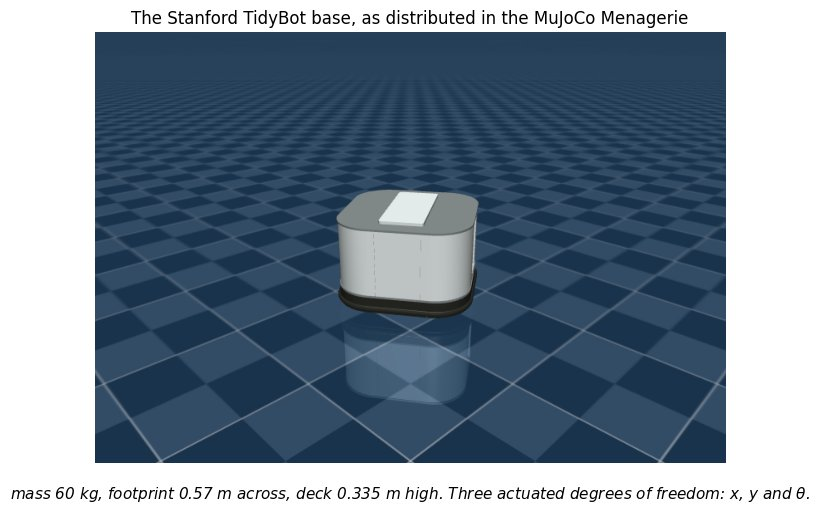

Every number below is read from the model, not typed in.

In [ ]:
facts = lab.base_facts()
print("mass        %.1f kg" % facts["mass"])
print("footprint   %.3f m across, deck %.3f m high"
      % (facts["footprint"], facts["deck"]))
print("degrees of freedom %d, all actuated" % facts["nq"])
for name, kind, axis in facts["joints"]:
    print("   %-9s %-6s axis %s" % (name, kind, axis))
print()
print("speed limit %.1f m/s, turn limit %.1f rad/s" % (lab.V_MAX, lab.W_MAX))

A **degree of freedom** is one independent way the model can move. This model has three: it can slide along $x$, slide along $y$, and turn about the vertical axis (a *hinge*). **Actuated** means a motor drives that motion.

So the simulated chassis *could* slide sideways. The controller in this notebook never asks it to: every command it sends is a forward speed and a turn rate, and nothing else (assumption 2 below).

### **1.3 Modelling assumptions**

The assumptions taken in developing the model of this system are provided in the table below.

| # | Assumption | Why it is reasonable |
| --- | --- | --- |
| 1 | Motion is planar | The floor is flat and the robot cannot leave it |
| 2 | The robot cannot move sideways | It is driven as a two-wheeled robot: forward speed and turn rate only [1]. The simulated chassis could slide sideways, but the controller never commands it |
| 3 | The drive delivers the commanded speed at once | The robot's own motor controllers (the **inner speed loop**) react much faster than our controller, which sends a new command 10 times a second (10 **Hz**). Tested in [Section 6](#scrollTo=section-6) |
| 4 | No mass, no motors, no friction | None of these bends the path. The missing sideways direction does |
| 5 | The robot is a disc of radius 0.30 m | The chassis is 0.567 m across, so a 0.30 m disc covers it with a little to spare |
| 6 | The position is known exactly | A real robot works out its position from sensor readings, using an **estimator**. None is modelled here |

### **1.4 The task**

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
lab.draw_room(ax)
plt.show()

print("start (%.1f, %.1f), goal (%.1f, %.1f)"
      % (lab.START[0], lab.START[1], lab.GOAL[0], lab.GOAL[1]))

The black dot is the start and the green cross is the goal. There are no walls in this problem: the robot works on an open floor, and the plots show the 5 m by 4 m area it uses.

The dotted ring around each item of equipment is the **keep-out zone**. It is much larger than the equipment, and the figure below shows why. The grey line in it is a path from the controller you will build in [Section 5](#scrollTo=section-5); for now, look only at the rings.

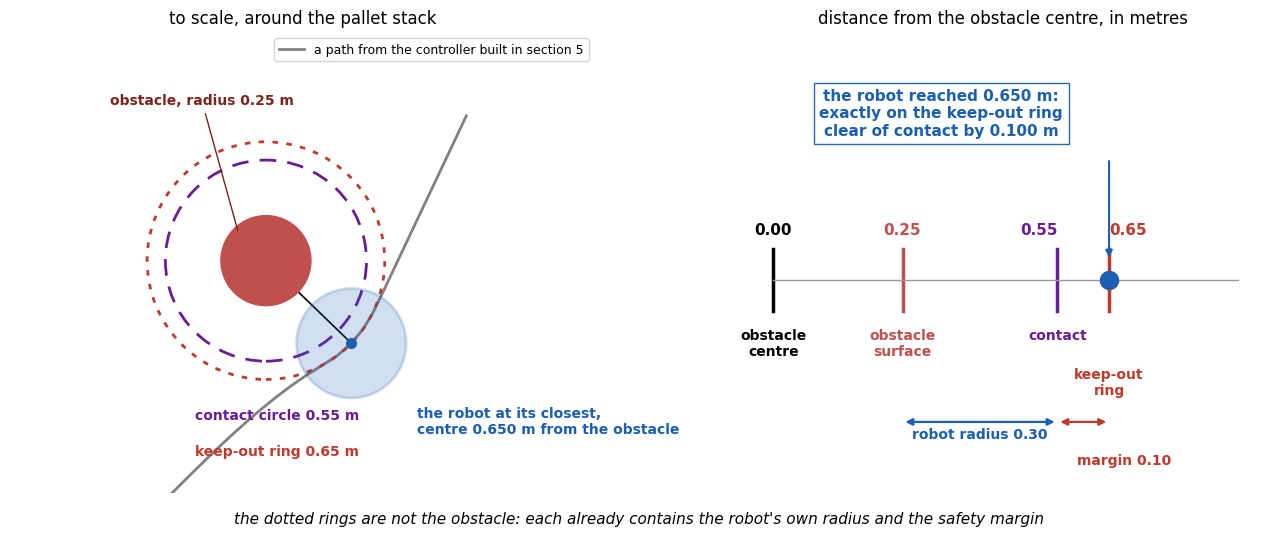

## **2. The model**

### **2.1 What you need to know to plan a path**

To plan a path you need three things:

1. where the robot is,
2. which way it is facing,
3. how the commands change those values.

You do not need its mass, because you are not choosing forces.

So the state is three numbers and the command is two:

$$\mathbf{s} = \begin{bmatrix} x \\ y \\ \theta \end{bmatrix}, \qquad \mathbf{u} = \begin{bmatrix} v \\ \omega \end{bmatrix}$$

Here $x$ and $y$ are the position in metres and $\theta$ is the **heading**, the direction the robot faces, in radians. The position on its own is written $\mathbf{p} = (x, y)$; the figures label its two parts $p_x$ and $p_y$. $v$ is the forward speed and $\omega$ (omega) is the turn rate.

In the robot's own frame it can drive forward at $v$ and turn at $\omega$. It **cannot** move sideways.

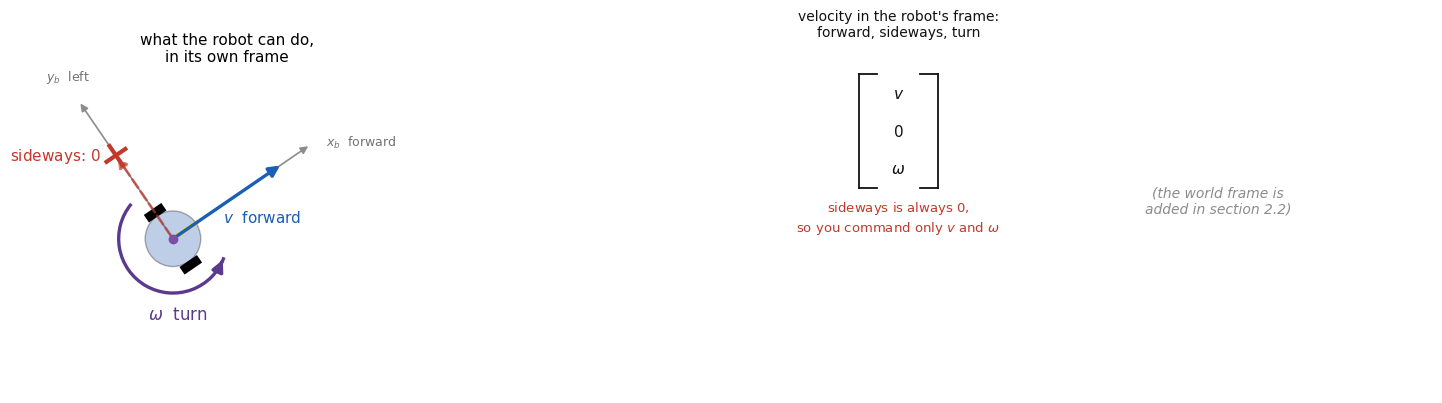

The robot frame turns with the robot; the world frame does not. They are also called the **body-fixed** frame and the **earth-fixed** frame.

In [ ]:
lab.video("robot_rotation")

### **2.2 The model**

A dot over a symbol means its rate of change with time: $\dot x$ is how fast $x$ is changing, in m/s.

Transform the velocity from the robot's frame into the world frame by rotating it through the heading:

$$\begin{bmatrix}\dot x\\ \dot y\\ \dot\theta\end{bmatrix} = \begin{bmatrix}\cos\theta & -\sin\theta & 0\\ \sin\theta & \cos\theta & 0\\ 0 & 0 & 1\end{bmatrix}\begin{bmatrix}v\\ 0\\ \omega\end{bmatrix}$$

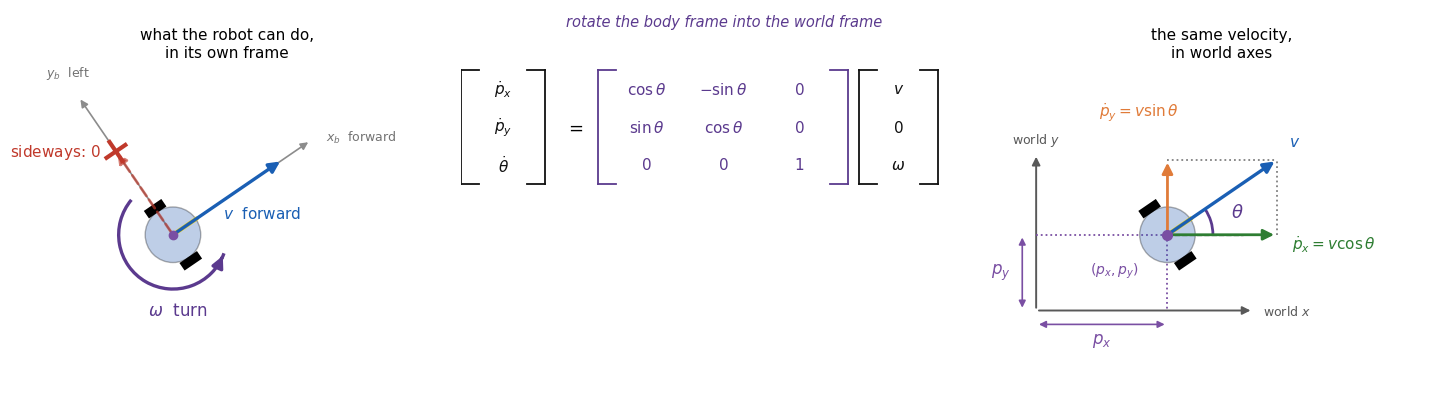

The zero removes the middle column, and what is left is the model:

$$\dot x = v\cos\theta, \qquad \dot y = v\sin\theta, \qquad \dot\theta = \omega$$

The controller works in steps of $\Delta t = 0.1$ s. Over one short step, treat the heading as constant; then each change is rate × time. This is called an **Euler step**. A $^{+}$ marks the value one step later:

$$x^{+} = x + \Delta t\,v\cos\theta, \qquad y^{+} = y + \Delta t\,v\sin\theta, \qquad \theta^{+} = \theta + \Delta t\,\omega$$

Call this whole step $F$, so that $\mathbf{s}^{+} = F(\mathbf{s}, \mathbf{u})$.

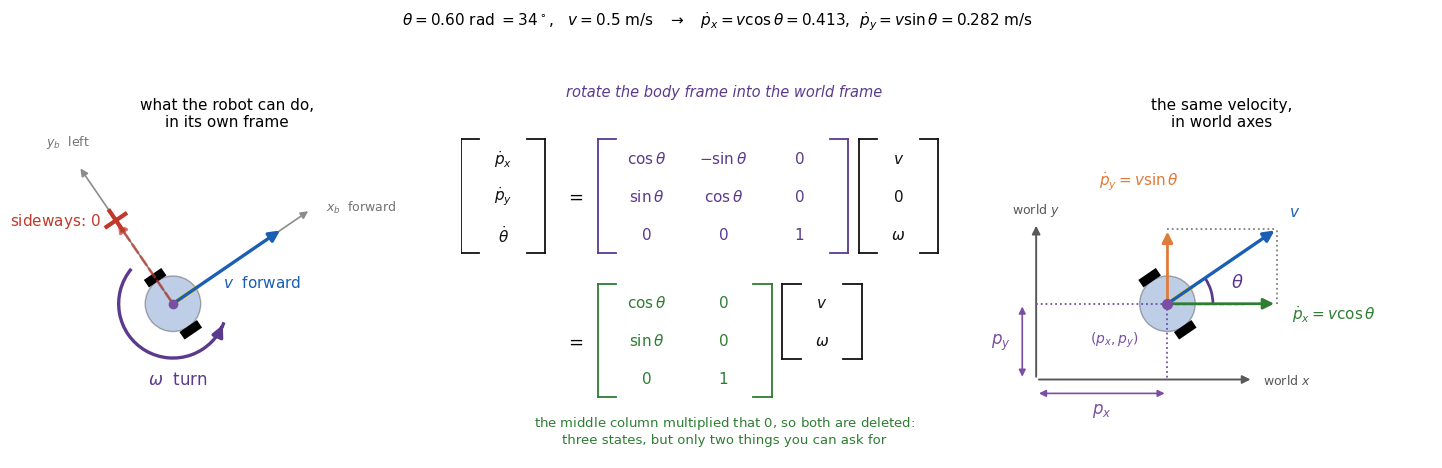

### **2.3 Could one fixed command do the job?**

[Section 1.1](#scrollTo=section-1-1) asked for a speed and a turn rate that take the robot to the inspection point without hitting anything. The model is now written, so the question can be tested.

Start with the simplest possible answer: **pick one command and hold it**. The figure shows what happens over 2.5 s.

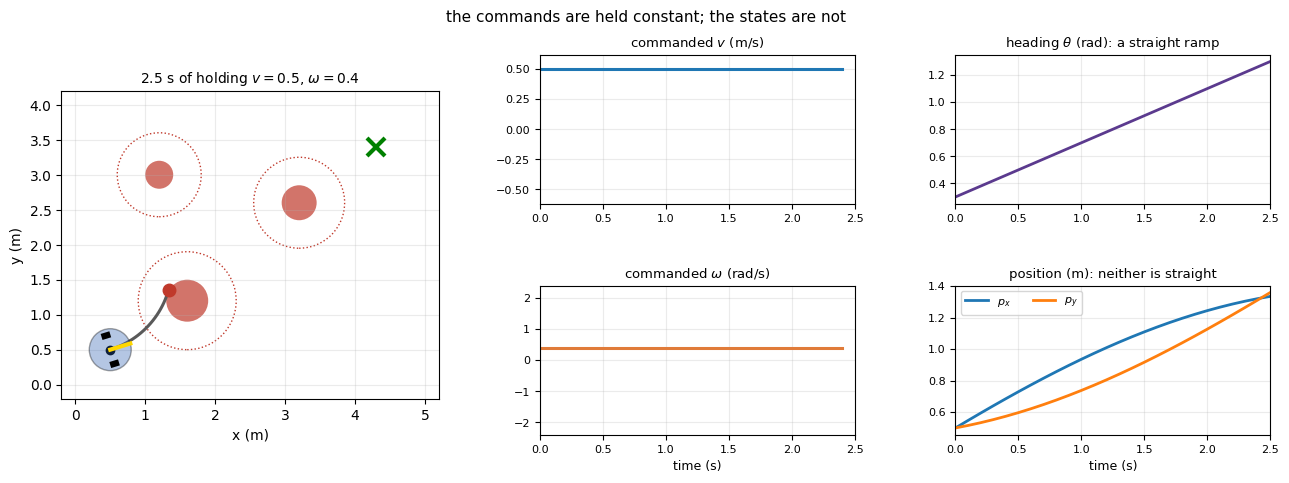

```text
both commands are held at the same value for the whole 2.5 s
heading turns 1.00 rad, which is exactly omega x time = 1.00
the robot ends 1.20 m from where it started, facing a different way
```

It fails. With both commands held, the robot drives round one circle (or along one straight line, if $\omega = 0$). This circle runs into the machine base.

You could search for a luckier circle, but no held command can do the whole job: the robot must also **stop** at the inspection point, and a held forward speed never stops.

So the command must **change as the journey goes on**: a different pair at every step. At 10 steps a second over 2.5 s that is fifty numbers to choose, and each one affects everything that follows.

Choosing many numbers at once, to make something as good as possible, while obeying rules, is an **optimisation problem**. [Section 3](#scrollTo=section-3) states that problem and solves it.

## **3. The approach, and the algorithm**

### **3.0 The method**

The control problem from [Section 1.1](#scrollTo=section-1-1) has three parts:

1. reach a goal the robot cannot drive straight to,
2. respect the speed and turn limits,
3. keep clear of the equipment.

A fixed command meets none of them. A hand-tuned rule, such as "turn towards the goal and drive at full speed", can meet the first two, but has no way of looking ahead at the third.

The method that meets all three is this: **choose the commands by solving an optimisation problem over a short window of the future, apply only the first one, then solve again.** That is **nonlinear model predictive control** (NMPC).

* *Model predictive*: it uses the model of [Section 2](#scrollTo=section-2) to predict where each choice of commands would take the robot.
* *Nonlinear*: the model contains $\cos\theta$ and $\sin\theta$, so doubling a command does not simply double its effect.

Why solve again? In short, the robot never moves exactly as the model predicts, so each plan goes out of date. [Section 6](#scrollTo=section-6) shows the controller coping with this on a simulated robot.

### **3.1 Optimisation in one number**

Suppose you may choose one number $u$, and the cost of your choice is

$$J(u) = (u-3)^2$$

The search starts at a poor guess. At each guess it measures the slope of $J$ and takes a step downhill.

In [ ]:
lab.video("bowl_free")

Now add a rule, called a **constraint**: $u \geq 5$. The best allowed choice is no longer at the bottom.

In [ ]:
lab.video("bowl_constrained")

It stops at exactly $u = 5$. **The answer sits on the boundary.** That happens twice more in this notebook: the path rides exactly along a keep-out ring ([Section 5](#scrollTo=section-5)), and the planned speed sits exactly on its limit (the plan figure in [Section 7](#scrollTo=section-7)).

### **3.2 Cost, and what the weights mean**

The controller must be told what a good path is. It is told with a **cost**: a number that is large when things are bad. Two things are bad here, being far from the goal and using the motors hard, so the cost charged at one step is

$$\underbrace{q\,\lVert \mathbf{p}_k - \mathbf{p}_{\text{goal}} \rVert^2}_{\textbf{still far from the goal}} \;+\; \underbrace{r\,\lVert \mathbf{u}_k \rVert^2}_{\textbf{using the motors}}$$

Here $k$ counts the steps of a plan: $\mathbf{p}_k$ is the predicted position at step $k$ and $\mathbf{u}_k = (v_k, \omega_k)$ is the command at step $k$. $\lVert\cdot\rVert^2$ is a squared length, shown in the next figure.

$q$ and $r$ are **weights**: numbers you choose. They decide which of the two the controller minds more. The two terms have different units (m² for the first, and (m/s)² plus (rad/s)² for the second); the weights turn both into plain numbers that can be added. Here $r = 0.01$ is small, so using the motors is cheap next to being far from the goal.

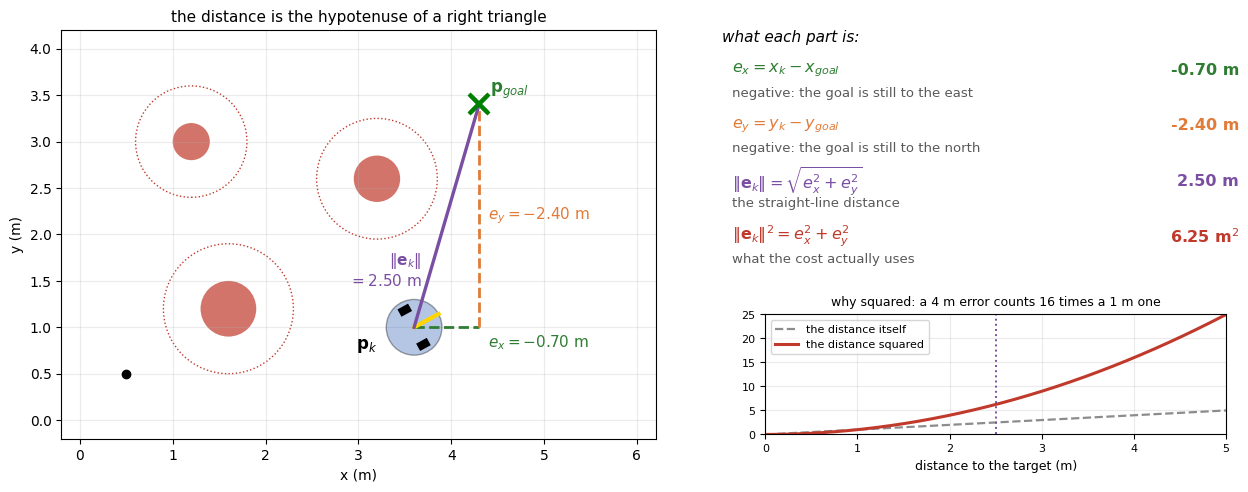

### **3.2b Names for the pieces**

Writing $\mathbf{p}_k - \mathbf{p}_{\text{goal}}$ every time becomes long, so from here on it is shortened to $\mathbf{e}_k$, the **error** at step $k$. Three pieces of the cost get names too.

| symbol | meaning | in code |
| --- | --- | --- |
| $\mathbf{e}_k$ | the error at step $k$: $\mathbf{p}_k - \mathbf{p}_{\text{goal}}$, how far from the goal | `X[:2, k] - goal` |
| $\ell$ | the cost of **one** step, $\ell(\mathbf{e}_k, \mathbf{u}_k)$ | `my_stage_cost` |
| $V_f$ | the cost of the **last** step, $V_f(\mathbf{e}_N)$ | `my_terminal_cost` |
| $J$ | the cost of the **whole plan** | `my_total_cost` |

In the code column, `X` holds the predicted states, one column per step, so `X[:2, k]` is $\mathbf{p}_k$. Task 4 builds it.

$$J \;=\; \underbrace{\sum_{k=0}^{N-1} \ell(\mathbf{e}_k, \mathbf{u}_k)}_{\textbf{every step}} \;+\; \underbrace{V_f(\mathbf{e}_N)}_{\textbf{the last one, again}}$$

$J$ is the number the optimiser makes as small as it can.

**Why charge the last step again?** A plan stops after $N$ steps whether or not the robot has arrived. A heavy charge on where the plan **ends** pulls the end of every plan towards the goal.

### **3.3 The problem, written out**

$$
\begin{aligned}
\min_{\mathbf{u}_0,\,\dots,\,\mathbf{u}_{N-1}} \quad
& \sum_{k=0}^{N-1}\Big( q\,\lVert \mathbf{p}_k - \mathbf{p}_{\text{goal}}\rVert^2
   + r\,\lVert \mathbf{u}_k \rVert^2 \Big)
   \;+\; q_N\,\lVert \mathbf{p}_N - \mathbf{p}_{\text{goal}}\rVert^2 \\[6pt]
\text{subject to}\quad
& \mathbf{s}_0 = \hat{\mathbf{s}} && \text{start where the robot is} \\
& \mathbf{s}_{k+1} = F(\mathbf{s}_k, \mathbf{u}_k)
   && \text{the model} \\
& \lvert v_k \rvert \le 1.0\ \mathrm{m/s},\quad
  \lvert \omega_k \rvert \le 1.5\ \mathrm{rad/s}
   && \text{what the robot can do} \\
& \lVert \mathbf{p}_k - \mathbf{p}_{\mathrm{obs}} \rVert^2
   \ \ge\ (r_{\mathrm{obs}} + R + \delta)^2
   && \text{keep clear}
\end{aligned}
$$

Read it as: choose the commands that make the total cost as small as possible, **subject to** (that is, while obeying) the rules underneath.

| symbol | meaning |
| --- | --- |
| $\min$ | make the expression as small as possible by choosing the commands $\mathbf{u}_0, \dots, \mathbf{u}_{N-1}$ written beneath it |
| $N$ | the number of steps in a plan, called the **horizon**. Here $N = 25$, so each plan looks 2.5 s ahead |
| $\hat{\mathbf{s}}$ | "s hat", the **measured** state: where the robot actually is when the plan is made |
| $F$ | the one-step model from [Section 2.2](#scrollTo=section-2-2) |
| $\mathbf{p}_{\mathrm{obs}}$ | the centre of an item of equipment; $r_{\mathrm{obs}}$ is its radius |
| $R$, $\delta$ | the robot radius (0.30 m) and the safety margin (0.10 m) |

Careful: $r$ on its own is the effort weight; $r_{\mathrm{obs}}$ is a radius.

The numbers the solver may choose are called the **decision variables**. Here they are the $2N$ commands. The predicted states are not chosen separately: they follow from the commands through $F$. This is the standard model predictive control problem [2].

### **3.4 The window, and the loop**

A plan is $N$ steps long, but only its first command is ever used. The robot moves for one step, its new position is measured, and the whole problem is solved again from there.

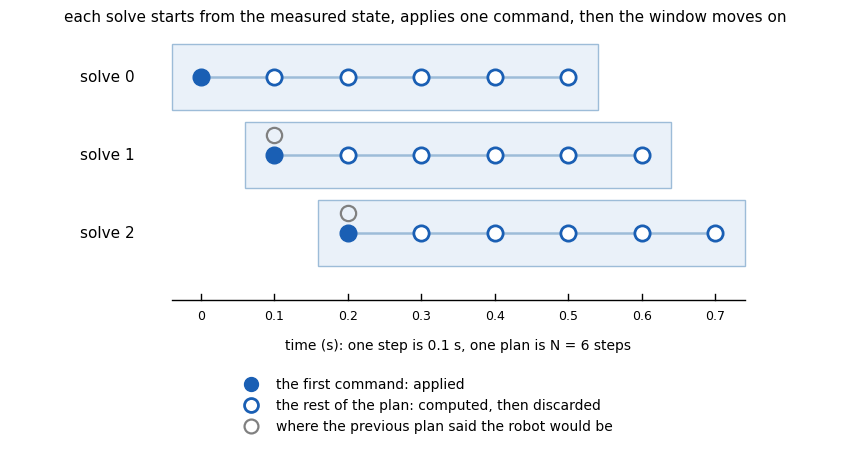

Two loops are running.

1. The inner loop is the search, inside the controller. It is done by **IPOPT**, a standard solver for problems like [Section 3.3](#scrollTo=section-3-3).
2. The outer loop is **feedback**: the measured position goes back into the next solve.

**MuJoCo** is a physics simulator. Here it plays the part of the real robot. The orange box lists what MuJoCo has that the model does not: the robot's 60 kg mass, and **servo lag**, the short time its drive motors take to reach a new commanded speed.

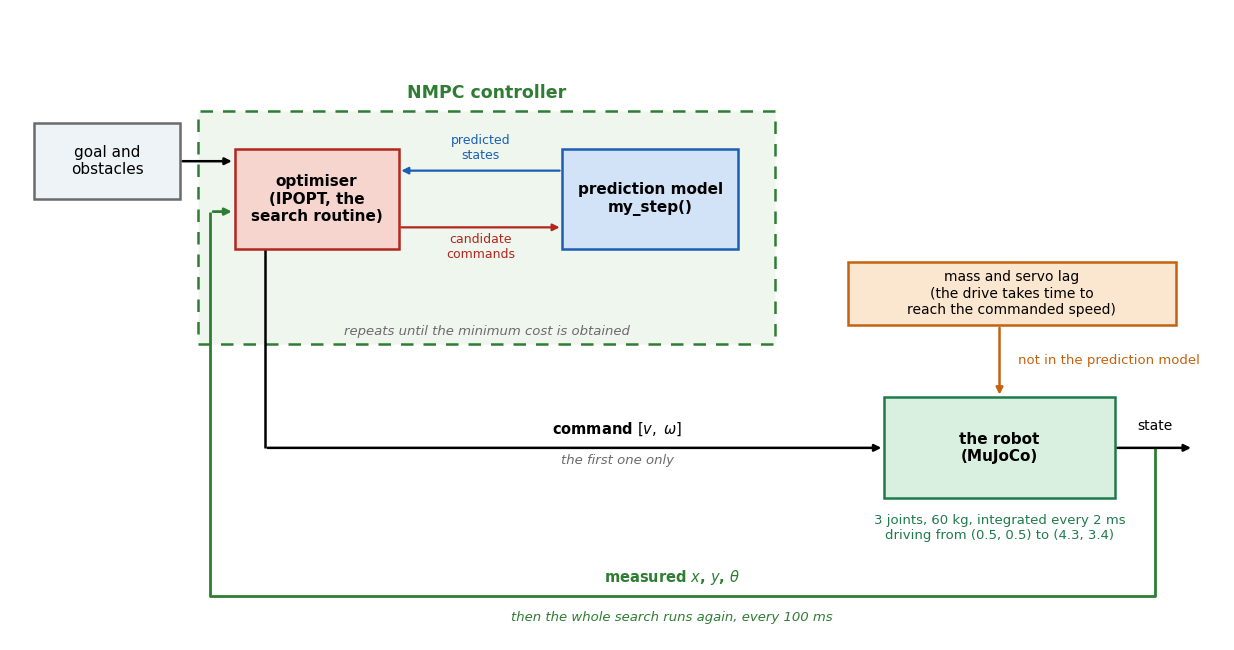

## **4. Building the parts**

Each part of the problem in [Section 3.3](#scrollTo=section-3-3) becomes code you write.

| part of the problem | what you write | task |
| --- | --- | --- |
| $F$ | `my_step` | 1 |
| $\ell$, $V_f$ and $J$ | `my_stage_cost`, `my_terminal_cost`, `my_total_cost` | 2 |
| the keep-out constraint | `my_obstacle` | 3 |
| the predicted states | `my_rollout` | 4 |
| applying the plan | two lines | 5 |

Run the check after each one. It must print **PASS**.

### **A note on notation**

Write the tasks with CasADi's functions, not NumPy's:

| instead of | write |
| --- | --- |
| `np.cos`, `np.sin` | `ca.cos`, `ca.sin` |
| `np.array([a, b, c])` | `ca.vertcat(a, b, c)` |
| `e @ e` | `ca.dot(e, e)` |

**Why.** When the controller is built in [Section 5](#scrollTo=section-5), your functions are not called with numbers. They are called with **symbols**: placeholders, like the $x$ in algebra, which CasADi uses to record the formula itself. From the recorded formula, CasADi works out the exact slope that the search of [Section 3.1](#scrollTo=section-3-1) needs.

NumPy's functions accept only numbers, so they fail on symbols. CasADi's versions accept both, so the function you test here with numbers is the same function the controller runs.

### **Task 1: write one step of the model**

Write `my_step(s, u, dt)`. It takes the state now and returns the state **one step later**, as a column of three numbers.

$$x^{+} = x + \Delta t\,v\cos\theta, \qquad y^{+} = y + \Delta t\,v\sin\theta, \qquad \theta^{+} = \theta + \Delta t\,\omega$$

These are the three rows of the answer, in this order.

**What you are given.**

| in code | in the equation |
| --- | --- |
| `s[0]`, `s[1]`, `s[2]` | $x$, $y$, $\theta$ |
| `u[0]`, `u[1]` | $v$, $\omega$ |
| `dt` | $\Delta t$ |

**What to do.** Fill in the three rows, in order.

In [ ]:
def my_step(s, u, dt):
    return ca.vertcat(
        ...,
        ...,
        ...,
    )


lab.check_step(my_step)

<details>
<summary>Hint</summary>

The heading is `s[2]`, the forward speed is `u[0]` and the turn rate is `u[1]`.
</details>

<details>
<summary>Solution</summary>

```python
s[0] + dt * u[0] * ca.cos(s[2]),
s[1] + dt * u[0] * ca.sin(s[2]),
s[2] + dt * u[1],
```
</details>

### **Task 2: write the cost, in three small functions**

Three short functions in one cell, one for each name in [Section 3.2b](#scrollTo=section-3-2b). Each has its own check.

**(a) The cost of one step.** `my_stage_cost(e, u, w)` returns one number:

$$\ell = \underbrace{q\,\lVert \mathbf{e} \rVert^2}_{\textbf{still far from the goal}} + \underbrace{r\,\lVert \mathbf{u} \rVert^2}_{\textbf{using the motors}}$$

**(b) The cost of the last step.** `my_terminal_cost(e, w)` returns one number:

$$V_f = q_N\,\lVert \mathbf{e}_N \rVert^2$$

There is no command term, because no command is applied after the last step.

**(c) The cost of the whole plan.** `my_total_cost(X, U, goal, w)` returns one number:

$$J = \sum_{k=0}^{N-1} \ell(\mathbf{e}_k, \mathbf{u}_k) \;+\; V_f(\mathbf{e}_N)$$

The sum uses (a) once per step; the last term uses (b) once. In code, $\mathbf{e}_k$ is `X[:2, k] - goal`, $\mathbf{u}_k$ is `U[:, k]`, and $\mathbf{e}_N$ is `X[:2, N] - goal`.

**What you are given.**

| in code | meaning |
| --- | --- |
| `e` | the position error, two numbers |
| `u` | the command, two numbers |
| `w["q"]`, `w["r"]`, `w["qN"]` | the weights $q$, $r$ and $q_N$. `w` is a dictionary of weights; it has nothing to do with the turn rate $\omega$ |
| `ca.dot(e, e)` | $\lVert \mathbf{e} \rVert^2$ |
| `X` | the predicted states: 3 rows, $N+1$ columns, column `k` is $\mathbf{s}_k$ |
| `U` | the commands: 2 rows, $N$ columns |
| `goal` | the target position, two numbers |

Note the slice `X[:2, k]`: only rows 0 and 1, $x$ and $y$, enter the cost, because the robot is not asked to finish at any particular heading.

**What to do.**

1. In (a), add the two terms and return the sum.
2. In (b), return the single term.
3. In (c), inside the loop add a stage cost for step `k`. After the loop, add the terminal cost once, for column `N`.

In [ ]:
def my_stage_cost(e, u, w):
    return ...


def my_terminal_cost(e, w):
    return ...


def my_total_cost(X, U, goal, w):
    N = U.shape[1]
    J = 0
    for k in range(N):
        J = J + ...
    J = J + ...
    return J


lab.check_stage_cost(my_stage_cost)
lab.check_terminal_cost(my_terminal_cost)
lab.check_total_cost(my_total_cost)

<details>
<summary>Hint</summary>

(a) is `w["q"]` times `ca.dot(e, e)`, plus the same shape for `u` with `w["r"]`. (b) is the first term of (a) with the weight `w["qN"]`. In (c), call (a) with `X[:2, k] - goal` and `U[:, k]`, then call (b) with `X[:2, N] - goal`.
</details>

<details>
<summary>Solution</summary>

```python
def my_stage_cost(e, u, w):
    return w["q"] * ca.dot(e, e) + w["r"] * ca.dot(u, u)


def my_terminal_cost(e, w):
    return w["qN"] * ca.dot(e, e)


def my_total_cost(X, U, goal, w):
    N = U.shape[1]
    J = 0
    for k in range(N):
        J = J + my_stage_cost(X[:2, k] - goal, U[:, k], w)
    J = J + my_terminal_cost(X[:2, N] - goal, w)
    return J
```
</details>

With $q_N = 100$ against $q = 10$, where a plan **ends** counts ten times as much as any single step on the way.

### **Task 3: write the keep-out constraint**

Write `my_obstacle(p, centre, radius, margin)`. It returns **one number**, which must be **positive when the robot is clear** of the obstacle and negative when it is too close.

$$g(\mathbf{p}) = \lVert \mathbf{p} - \mathbf{p}_{\mathrm{obs}} \rVert^2 - (r_{\mathrm{obs}} + R + \delta)^2 \ \ge\ 0$$

The first term is the squared distance from the obstacle centre, `ca.dot(d, d)`. The bracket is the smallest allowed distance.

**What you are given.**

| in code | in the equation |
| --- | --- |
| `p` | $\mathbf{p}$, the robot position |
| `centre`, `radius` | $\mathbf{p}_{\mathrm{obs}}$ and $r_{\mathrm{obs}}$ |
| `margin` | $\delta$ |
| `lab.R_ROBOT` | $R$, the robot radius |
| `d` | $\mathbf{p} - \mathbf{p}_{\mathrm{obs}}$, already written for you |

**What to do.**

1. Set `safe` to the smallest allowed distance.
2. Return the squared distance minus the square of `safe`.

In [ ]:
def my_obstacle(p, centre, radius, margin):
    d = p - ca.DM(centre)
    safe = ...
    return ...


lab.check_obstacle(my_obstacle)

<details>
<summary>Hint</summary>

The robot radius is `lab.R_ROBOT`. Use `ca.dot(d, d)` for the squared distance.
</details>

<details>
<summary>Solution</summary>

```python
safe = radius + lab.R_ROBOT + margin
return ca.dot(d, d) - safe ** 2
```
</details>

Squared distances are used on both sides because $\sqrt{\cdot}$ has an infinitely steep slope at zero, which the search of [Section 3.1](#scrollTo=section-3-1) cannot use. (`ca.DM` turns the plain numbers in `centre` into a CasADi column, so that it can be subtracted from `p`.)

### **Task 4: predict where a whole plan would take the robot**

Write `my_rollout(s0, U, dt)`. It takes a starting state and a whole sequence of commands, and returns **every state along the way**.

$$\mathbf{s}_{k+1} = F(\mathbf{s}_k, \mathbf{u}_k), \qquad k = 0, 1, \dots, N-1$$

In code, $F$ is your `my_step` from Task 1, $\mathbf{s}_k$ is `X[-1]` and $\mathbf{u}_k$ is `U[:, k]`. Each new state becomes the next item added to `X`.

**What you are given.** `s0` is the starting state. `U` has 2 rows and $N$ columns, one column per step. `X` starts as a list holding `s0`; `X[-1]` is the last state added so far.

**What to return.** A matrix with 3 rows and $N+1$ columns: the starting state, then one column per step. The last line of the cell, `ca.horzcat`, joins the list into that matrix for you.

In [ ]:
def my_rollout(s0, U, dt):
    X = [s0]
    for k in range(U.shape[1]):
        X.append(...)
    return ca.horzcat(*X)


lab.check_rollout(my_rollout)

<details>
<summary>Hint</summary>

The last state so far is `X[-1]`, and the command for step `k` is `U[:, k]`.
</details>

<details>
<summary>Solution</summary>

```python
my_step(X[-1], U[:, k], dt)
```
</details>

You have now written every formula in [Section 3.3](#scrollTo=section-3-3). What is left is the search itself.

## **5. The complete algorithm**

### **5.1 Assembling the parts**

Your functions now build the optimisation problem. `build` below does it in five moves.

1. `opti = ca.Opti()` starts an empty problem.
2. `U = opti.variable(2, N)` creates the decision variables: the $2N$ commands the solver may choose. `s0` and `goal` are **parameters**: numbers the solver may not change, filled in before each solve.
3. `X = my_rollout(...)` predicts the states from the commands, and `opti.minimize(...)` makes $J$ the thing to minimise. Because `U` holds symbols, `X` and $J$ are recorded formulas, not numbers.
4. The `subject_to` lines add the constraints. `opti.bounded(a, x, b)` means $a \le x \le b$. The keep-out constraint starts at step 1, because step 0 is the measurement, which nothing can change.
5. `opti.solver("ipopt", ...)` chooses IPOPT for the search. The options only silence its printout.

The first line of `build` checks that Tasks 1 to 4 are finished, and says which one is not.

CasADi [3] differentiates the recorded formulas exactly, which is why each solve takes milliseconds.

In [ ]:
def build(N=25, dt=0.1, w=None, margin=0.10):
    lab.require_finished(my_step, my_stage_cost, my_terminal_cost,
                         my_total_cost, my_obstacle, my_rollout)
    w = w or {"q": 10.0, "r": 0.01, "qN": 100.0}
    opti = ca.Opti()
    U = opti.variable(2, N)
    s0 = opti.parameter(3)
    goal = opti.parameter(2)

    X = my_rollout(s0, U, dt)
    opti.minimize(my_total_cost(X, U, goal, w))

    for k in range(1, N + 1):          # k = 0 is the measurement
        for c in lab.OBSTACLES:
            opti.subject_to(my_obstacle(X[:2, k], (c[0], c[1]), c[2], margin) >= 0)
    opti.subject_to(opti.bounded(-lab.V_MAX, U[0, :], lab.V_MAX))
    opti.subject_to(opti.bounded(-lab.W_MAX, U[1, :], lab.W_MAX))

    opti.solver("ipopt", {"print_time": 0, "ipopt.print_level": 0,
                          "ipopt.sb": "yes"})
    return opti, X, U, s0, goal


print("the problem has %d commands to choose" % (2 * 25))

### **Explain 1: where are the limits?**

Point to the line in `build` that stops the robot going faster than 1.0 m/s, and the line that keeps it out of the rings. Then say, in one sentence, what the plan would do if the speed line were deleted.

*Your answer:*

<details>
<summary>Answer</summary>

The speed limit is `opti.subject_to(opti.bounded(-lab.V_MAX, U[0, :], lab.V_MAX))`: row 0 of `U` is $v$. The keep-out line is `opti.subject_to(my_obstacle(...) >= 0)`, inside the loop.

Without the speed limit, the only thing holding the speed down would be the small effort term $r\lVert\mathbf{u}\rVert^2$, so the plan would ask for speeds far above what the robot can deliver.
</details>

### **Task 5: close the loop**

Two lines. The solver has just returned a plan. Apply **only its first command**, then advance the robot with it.

$$\mathbf{u}_{\text{applied}} = \mathbf{u}_0, \qquad \hat{\mathbf{s}} \leftarrow F(\hat{\mathbf{s}}, \mathbf{u}_{\text{applied}})$$

The arrow means "is replaced by". In code, $\mathbf{u}_0$ is `Uopt[:, 0]` and $F$ is your `my_step`.

**What you are given.**

| in code | meaning |
| --- | --- |
| `Uopt` | the plan: 2 rows, $N$ columns |
| `s` | $\hat{\mathbf{s}}$, where the robot is now |
| `ps`, `pg` | the parameters `s0` and `goal` from `build` |
| `0.1` | the time step, the `dt` in `build` |

In this loop the robot is simulated by your own `my_step`: the model plays the part of the real robot until [Section 6](#scrollTo=section-6).

**What to do.**

1. Set `u` to the first column of the plan.
2. Set `s` to the state one step later, using Task 1, and turn the result into plain numbers with `np.array(...).ravel()`.

The other $N-1$ commands are thrown away.

In [ ]:
opti, X, U, ps, pg = build()

s = np.array([0.5, 0.5, 0.3])
path = [s.copy()]

for step in range(90):
    opti.set_value(ps, s)
    opti.set_value(pg, lab.GOAL)
    sol = opti.solve()
    Uopt = np.array(sol.value(U))

    u = ...
    s = ...
    lab.stop_unless(u is not ... and s is not ...,
                    "write the two lines for u and s above, then run this cell again.")

    path.append(np.array(s).ravel())
    opti.set_initial(U, Uopt)      # start the next search from this plan

path = np.array(path)
lab.check_loop(path)

<details>
<summary>Hint</summary>

The first command is column 0: `Uopt[:, 0]`. Advance with `my_step(s, u, 0.1)`.
</details>

<details>
<summary>Solution</summary>

```python
u = Uopt[:, 0]
s = np.array(my_step(s, u, 0.1)).ravel()
```
</details>

### **5.2 The result**

In [ ]:
lab.stop_unless(lab.is_path(globals().get("path")),
                "finish Task 5 first, then run this cell again.")

fig, ax = plt.subplots(figsize=(6.4, 5.2))
lab.draw_room(ax)
ax.plot(path[:, 0], path[:, 1], lw=2.5, color="red",
        label="your controller")
ax.legend(loc="lower right", fontsize=9)
plt.show()

**That is nonlinear model predictive control.** You wrote every formula in it; the search itself is IPOPT's.

The check printed that the closest approach is exactly on a ring. The path runs along the machine base's keep-out ring, just as the one-number search stopped exactly on its wall in [Section 3.1](#scrollTo=section-3-1). The constraint is **active** there: it, not the cost, decides where the path goes.

Because the robot here is the model itself, each new plan starts exactly where the previous plan predicted. Re-solving has had nothing to correct yet. [Section 6](#scrollTo=section-6) changes that.

## **6. On the simulated robot**

### **6.1 Swapping the plant**

Everything so far used the model as the robot: in your loop, `my_step` both made the prediction and moved the robot. The system being controlled is called the **plant**, so the model has been the plant.

Now the plant becomes MuJoCo: a 60 kg chassis whose drive motors are **servos** (motors that are told a speed and work to reach it), simulated every 2 ms. The controller does not change.

Your controller does not change either: from here on, every run uses the `build` you wrote in section 5.

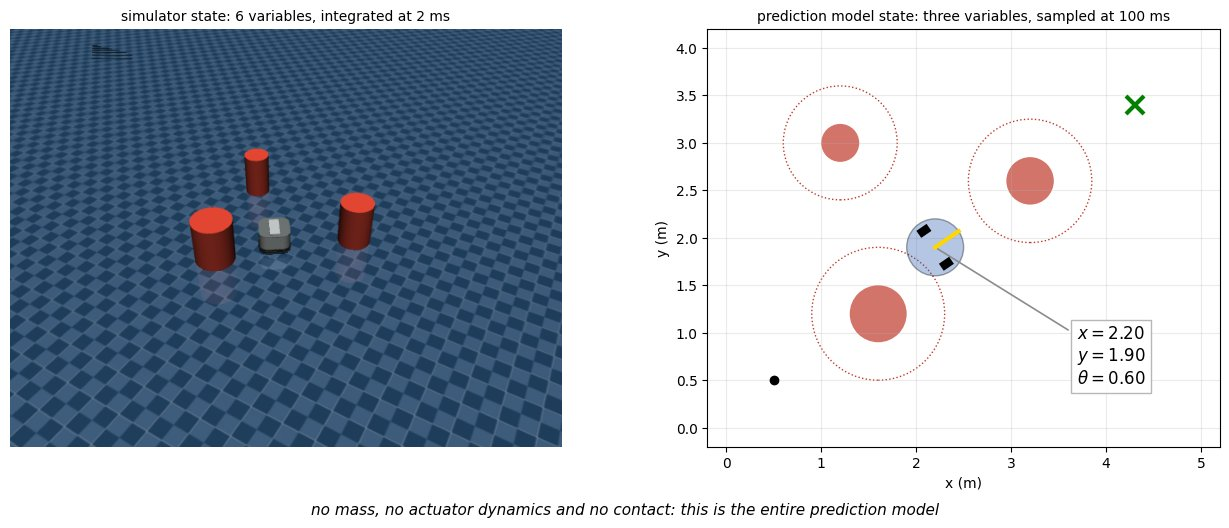

MuJoCo keeps six numbers for this robot: the three positions $x$, $y$, $\theta$ and their three rates. The model keeps three.

### **6.2 Your controller, flying the simulated robot**

This is your loop from Task 5, with one line changed: the robot is now MuJoCo instead of your own `my_step`. Everything else, the model, the cost, the constraints and the plan, is the code you wrote.

Three lines are also added around the solve. On the simulated robot the measured position sometimes sits a few millimetres inside a keep-out ring, and from there no plan can satisfy the constraint, so the solver reports that the problem is impossible. A real controller cannot stop at that point: it uses what is left of its previous plan and tries again at the next step. That happens about six times in this run.

In [ ]:
opti, X, U, ps, pg = build()

robot = lab.MuJoCoBase()                 # the simulated robot
s = robot.reset([0.5, 0.5, 0.3])
path_mj = [s.copy()]
Uopt = np.zeros((2, 25))

for step in range(90):
    opti.set_value(ps, s)
    opti.set_value(pg, lab.GOAL)
    try:
        sol = opti.solve()
        Uopt = np.array(sol.value(U))
    except RuntimeError:                 # no plan from here: reuse the last one
        Uopt = np.hstack([Uopt[:, 1:], Uopt[:, -1:]])

    u = Uopt[:, 0]
    s = robot.step(u[0], u[1], 0.1)      # the one change: MuJoCo, not my_step

    path_mj.append(s.copy())
    opti.set_initial(U, Uopt)

path_mj = np.array(path_mj)
lab.path_report(path_mj)

In [ ]:
lab.stop_unless(lab.is_path(globals().get("path")) and
                lab.is_path(globals().get("path_mj")),
                "run Task 5 and the cell above first, then run this cell again.")

lab.plot_paths({"the model as the robot (Task 5)": path,
                "MuJoCo as the robot": path_mj},
               "your controller, on two robots")

The two paths almost coincide. On MuJoCo the robot cuts 9 mm inside the machine base's keep-out ring: the servos take a moment to reach each new speed, so the robot does not turn exactly when the plan said. It is still 91 mm from touching, which is what the margin is for.

The feedback does the rest. Every 0.1 s the controller measures where the robot really is and plans again from there.

### **6.3 The same run, recorded**

`lab.run` is the loop you have just written, with the vehicle, the recording and a stopping test around it. It runs **your** `build`, so the path below is the one above. Recording each plan is what lets the animation draw the dashed line ahead of the robot.

Its report adds the timing: the robot reaches the goal after 5.6 s on MuJoCo, against 5.1 s with the model as the robot.

In [ ]:
log_mj = lab.run(build, lab.MuJoCoBase())

In [ ]:
lab.stop_unless("log_mj" in globals(), "run the cell above first, then run this cell again.")

lab.animate(log_mj)

The same run, inside MuJoCo itself.

In [ ]:
lab.stop_unless("log_mj" in globals(), "run the cell above first, then run this cell again.")

lab.animate_mujoco(log_mj)

## **7. The effect of the horizon**

$N$ is how many steps a plan contains, each 0.1 s long. **Try 5, then 25, then 50**, and note where the plan ends. This figure shows a single solve; the shaded band is the one step that is actually taken.

In [ ]:
lab.plot_plan(build, [0.5, 0.5, 0.3], N=25)        # EDIT: try 5, then 50

The next figure runs the whole journey on MuJoCo with four window lengths, using your controller each time. It takes about half a minute.

In [ ]:
lab.plot_horizon_vs_obstacle(build)

1. With $N = 4$ each plan sees only 0.4 s ahead. Every short plan that goes round the machine base first takes the robot away from the goal, which the cost punishes, so the robot stops against the machine base's keep-out ring and stays there.
2. $N = 5$ only just gets round, and by a different route: left of the machine base, then above the pallet stack. It arrives later (6.1 s) and cuts deeper into a ring (19 mm) than with a longer window. A short window sees only what is close, so small differences decide which way it goes.
3. With $N = 25$ the robot arrives after 5.6 s, 9 mm inside the ring.
4. $N = 50$ gives the same path as 25, but each solve takes far longer: the legend shows the time per solve on this computer. A new command is due every 0.1 s, so if a solve takes longer than that, a real robot could not run this controller. Long horizons are where the way the problem is written starts to matter: yours predicts each state from the one before, which is simple to write but slow for long plans.

So the horizon must be long enough to see a way round, and no longer than the computer can solve in time.

The boundary is sharp and depends on the plant. With the model as the robot, even $N = 5$ stops on the ring, as $N = 4$ does here: on MuJoCo, the small servo lag happens to nudge the robot off the stopping point.

## **8. In a future workshop**

This workshop ends here. A future workshop will look at:

1. **The weights.** How the weight on distance ($q$) and the weight on effort ($r$) change the path, and why a larger $q$ can change nothing while a speed limit is holding the speed.
2. **Open loop against re-solving.** Planning the whole journey in one solve, running it with nothing measured, and seeing what a start error of under six degrees does, compared with re-solving at every step.

## **9. References**

1. Siegwart, R., Nourbakhsh, I. R. and Scaramuzza, D. (2011) *Introduction to Autonomous Mobile Robots*. 2nd edn. Cambridge, MA: MIT Press.
2. Rawlings, J. B., Mayne, D. Q. and Diehl, M. M. (2017) *Model Predictive Control: Theory, Computation, and Design*. 2nd edn. Madison, WI: Nob Hill Publishing.
3. Andersson, J. A. E., Gillis, J., Horn, G., Rawlings, J. B. and Diehl, M. (2019) CasADi: a software framework for nonlinear optimization and optimal control. *Mathematical Programming Computation*, 11(1), pp. 1-36.
4. Todorov, E., Erez, T. and Tassa, Y. (2012) MuJoCo: a physics engine for model-based control. *IEEE/RSJ International Conference on Intelligent Robots and Systems*, pp. 5026-5033.
5. Zakka, K. et al. (2022) *MuJoCo Menagerie: a collection of high-quality simulation models for MuJoCo*. Available at: https://github.com/google-deepmind/mujoco_menagerie